In [ ]:
# PURPOSE: Import the libraries used in the project.
# pandas is for data cleaning/analysis, while seaborn and matplotlib are for visualizations.
# TALKING POINT: These are the main Python libraries I used throughout the analysis.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# PURPOSE: Load the two sales datasets and the customer dataset.
# Blank strings and text such as 'nan' are treated as missing values while reading the files.
# TALKING POINT: The sales data was split into two files, so I load both before combining them.

missingValues = ['','nan',"NAN"]
sales1 = pd.read_csv('sales_data_part1.csv',na_values = missingValues)
sales2 = pd.read_csv('sales_data_part2.csv',na_values = missingValues)
customers = pd.read_csv('customers.csv')
pd.set_option('display.max_columns', None)


In [ ]:
# PURPOSE: Combine both sales files into one DataFrame.
# ignore_index=True creates a new continuous row index after concatenation.
# TALKING POINT: This gives me one complete sales dataset to clean and analyze.

sales = pd.concat([sales1, sales2], ignore_index=True)


In [ ]:
# PURPOSE: Standardize column names so they are easier and safer to use in Python.
# I remove extra spaces, use lowercase letters, and replace spaces/hyphens with underscores.
# TALKING POINT: Consistent column names reduce errors later in the analysis.

sales.columns = sales.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

In [ ]:
# PURPOSE: Standardize important text columns.
# The function removes extra spaces and converts text to lowercase so values such as 'Online' and 'online' match.
# TALKING POINT: I normalize text before grouping or comparing categories.

text_cols = ['order_id','customer_id','product','product_code','sales_person','channel','country_code']
def standardize(x):
    return x.astype(str).str.strip().str.lower()

sales[text_cols] = sales[text_cols].apply(standardize)
sales.head()

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,0,0.03
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,0,0.05
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,0,0.05
3,ord0000004,2022-02-21,custj00002,jordn,website,ahmed,3,51.21,eg03,headset,0,0.02
4,ord0000005,2021-01-14,custj00002,jordn,website,rami,2,238.59,p02,tablet,0,0.05


In [ ]:
# PURPOSE: Check the dataset for missing values in several possible forms.
# I check real NaN values, empty strings, and text values that look like 'nan'.
# TALKING POINT: This helps identify data-quality problems before analysis.

sales.isna().sum()
(sales == '').sum()
(sales.apply(lambda col: col.astype(str).str.lower() == 'nan')).sum()


,0
order_id,0
date,0
customer_id,0
country_code,0
channel,5
sales_person,0
units_sold,0
unit_price,0
product_code,0
product,0


In [ ]:
# PURPOSE: Inspect the different values that appear in the channel column.
# TALKING POINT: I check the raw categories first so I know which inconsistent labels need to be standardized.

sales['channel'].unique()

array(['online', 'offline', 'website', 'in-store', 'nan'], dtype=object)

In [ ]:
# PURPOSE: Standardize sales-channel names.
# 'website' is grouped with 'online', and 'in-store' is grouped with 'offline'.
# TALKING POINT: Different labels that represent the same channel are combined into consistent categories.

channel_map = {
    "online": "online",
    "website": "online",
    "offline": "offline",
    "in-store": "offline",
}

sales["channel"] = sales["channel"].map(channel_map)


In [ ]:
# PURPOSE: Handle missing or unmapped channel values.
# Missing channel values are labeled 'unknown' instead of being silently removed.
# TALKING POINT: I keep incomplete records but clearly mark their missing channel information.

sales['channel'].replace('nan','unknown', inplace =True)
sales['channel'].fillna('unknown', inplace=True)
sales['channel'].unique()

/tmp/ipykernel_417/799030796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sales['channel'].replace('nan','unknown', inplace =True)
/tmp/ipykernel_417/799030796.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

array(['online', 'offline', 'unknown'], dtype=object)

In [ ]:
# PURPOSE: Identify all duplicated records for inspection.
# keep=False shows every copy of a duplicated row, not only the later copies.
# TALKING POINT: I inspect duplicates before removing them so I know what is being cleaned.

dupes_all = sales[sales.duplicated(keep=False)]
dupes_all

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent
711,ord0000664,2025-03-10,custj00089,jordan,offline,rami,3,6.24,e05,cable,0,0.05
1962,ord0001832,2023-05-11,custj00226,jordn,offline,ahmed,1,907.00,eb01,laptop,0,0.02
3443,ord0003191,2022-03-02,custj00407,jo,online,rami,3,47.69,eg03,headset,0,0.02
3574,ord0003316,2023-08-23,custj00410,jor,online,ali,1,162.98,m01,monitor,0,0.05
4239,ord0003927,2021-07-04,custj00486,jor,online,ahmed,5,31.44,e04,keyboard,0,0.05
4738,ord0004398,2021-10-21,custl00033,lebanon,online,sami,4,32.13,a01,accessory,0,0.03
7019,ord0006503,2024-06-11,custl00255,leb,online,lina,3,27.97,a01,accessory,0,0.03
7088,ord0006564,2022-08-18,custl00261,lebanon,online,lina,3,351.50,p02,tablet,0,0.03
8348,ord0007735,2023-06-26,custl00406,lebn,online,sami,1,27.08,a01,accessory,0,0.05
8462,ord0007841,2023-04-25,custl00421,lebn,online,lina,3,364.11,p02,tablet,0,0.05


In [ ]:
# PURPOSE: Remove duplicate rows while keeping the first occurrence.
# reset_index() creates a clean row index after removing duplicates.
# TALKING POINT: This prevents the same transaction record from being counted more than once.

sales = sales.drop_duplicates(keep='first').reset_index(drop=True)

In [ ]:
# PURPOSE: Verify that duplicate removal worked.
# A result of 0 means no fully duplicated rows remain.
# TALKING POINT: I validate my cleaning steps instead of assuming they worked.

sales.duplicated().sum()

np.int64(0)

In [ ]:
# PURPOSE: Recheck missing and blank values after the initial cleaning.
# TALKING POINT: This is a validation step to understand the remaining data-quality issues.

sales.isna().sum()
(sales == '').sum()
(sales.astype(str).apply(lambda col: col.str.lower().eq('nan'))).sum()


,0
order_id,0
date,0
customer_id,0
country_code,0
channel,0
sales_person,0
units_sold,0
unit_price,0
product_code,0
product,0


In [ ]:
# PURPOSE: Handle zero values in units_sold and inspect descriptive statistics.
# I chose to replace 0 units with 1 because I treated a zero-unit transaction as an invalid quantity.
# IMPORTANT TALKING POINT: This is a data-cleaning assumption made for this project.
# describe() then summarizes the numeric columns using count, mean, standard deviation, minimum, maximum, etc.

sales['units_sold'] = sales['units_sold'].replace(0, 1)
sales.describe()


,units_sold,unit_price,promotion_flag,commission_percent
count,9147.000000,9147.000000,9147.000000,9147.000000
mean,2.777195,209.975015,0.010933,0.033443
std,1.505509,283.936197,0.103991,0.012518
min,1.000000,4.410000,0.000000,0.020000
25%,1.000000,30.575000,0.000000,0.020000
50%,3.000000,87.390000,0.000000,0.030000
75%,4.000000,248.400000,0.000000,0.050000
max,10.000000,1518.495638,1.000000,0.050000


In [ ]:
# PURPOSE: Inspect the structure and data types of the cleaned sales DataFrame.
# info() shows the number of rows, non-null counts, column names, and data types.
# TALKING POINT: I use this to confirm that the dataset structure is suitable for analysis.

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9147 entries, 0 to 9146
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            9147 non-null   object 
 1   date                9147 non-null   object 
 2   customer_id         9147 non-null   object 
 3   country_code        9147 non-null   object 
 4   channel             9147 non-null   object 
 5   sales_person        9147 non-null   object 
 6   units_sold          9147 non-null   int64  
 7   unit_price          9147 non-null   float64
 8   product_code        9147 non-null   object 
 9   product             9147 non-null   object 
 10  promotion_flag      9147 non-null   int64  
 11  commission_percent  9147 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 857.7+ KB


In [ ]:
# PURPOSE: Convert the date column from text into a real datetime data type.
# TALKING POINT: Datetime format is necessary for extracting year, month, and weekday later.

sales['date'] = pd.to_datetime(sales['date'] )

In [ ]:
# PURPOSE: Convert the promotion flag into a Boolean column.
# True means a promotion was active and False means it was not.
# TALKING POINT: Boolean values make the promotion indicator easier to interpret and analyze.

sales['promotion_flag'] = sales['promotion_flag'].astype(bool)

In [ ]:
# PURPOSE: Standardize inconsistent country codes into full country names.
# Different versions of Jordan and Lebanon codes are mapped to 'jordan' or 'lebanon'.
# Any code that cannot be recognized is labeled 'unknown'.
# TALKING POINT: This prevents the same country from appearing as several separate categories.

normal = sales['country_code'].astype(str).str.strip().str.lower()

country_map = {
    'jo':'jordan','jor':'jordan','jordn':'jordan','jordan':'jordan',
    'lb':'lebanon','lbn':'lebanon','leb':'lebanon','lebh':'lebanon','lebn':'lebanon','lebanon':'lebanon'
}
sales['country'] = normal.map(country_map).fillna('unknown')


In [ ]:
# PURPOSE: Preview the cleaned dataset after country standardization.
# TALKING POINT: I use head() as a quick visual check that the transformations look correct.

sales.head(10)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan
5,ord0000006,2025-05-19,custj00002,jordn,online,ahmed,3,48.64,eg03,headset,False,0.02,jordan
6,ord0000007,2022-09-18,custj00002,jordan,offline,ahmed,4,5.79,e05,cable,False,0.03,jordan
7,ord0000008,2021-05-29,custj00002,jordan,online,ahmed,4,6.25,e05,cable,False,0.03,jordan
8,ord0000009,2021-08-05,custj00002,jo,offline,sara,2,5.72,e05,cable,False,0.02,jordan
9,ord0000010,2021-03-11,custj00002,jo,offline,rami,3,157.18,eg02,gaming chair,False,0.05,jordan


In [ ]:
# PURPOSE: Convert all unit prices to a common currency: USD.
# Jordanian prices are multiplied by 1.41, while Lebanese values are kept unchanged according to the project data rules.
# TALKING POINT: A common currency is necessary for fair revenue comparisons between countries.

def convert_price(row):
    if row['country'] == 'jordan':
        return row['unit_price'] * 1.41
    elif row['country'] == 'lebanon':
        return row['unit_price']
    else:
        return None

sales['unit_price_usd'] = sales.apply(convert_price, axis=1)


In [ ]:
# PURPOSE: Preview the data after creating the USD price column.
# TALKING POINT: This is another quick validation step to confirm the new values were created correctly.

sales.head(5)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country,unit_price_usd
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan,1304.7153
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan,227.2638
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan,6.9654
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan,72.2061
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan,336.4119


In [ ]:
# PURPOSE: Calculate the revenue value of each transaction line.
# Formula: units sold × unit price in USD.
# TALKING POINT: total_amount becomes the main monetary measure used in later sales analysis.

sales['total_amount'] = (
    sales['units_sold'] * sales['unit_price_usd']
)

In [ ]:
# PURPOSE: Preview the dataset after calculating total transaction amounts.
# TALKING POINT: I check the calculated feature before using it in later questions.

sales.head(5)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country,unit_price_usd,total_amount
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan,1304.7153,1304.7153
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan,227.2638,1136.3190
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan,6.9654,20.8962
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan,72.2061,216.6183
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan,336.4119,672.8238


In [ ]:
# PURPOSE: Create time-based features from the date column.
# I extract year, month, and weekday name for trend and time-pattern analysis.
# TALKING POINT: Feature engineering makes it easier to answer questions about sales over time.

sales['year'] = sales['date'].dt.year
sales['month'] = sales['date'].dt.month
sales['weekday_name'] = sales['date'].dt.day_name()

In [ ]:
# PURPOSE: Preview the final prepared dataset before starting the business analysis.
# TALKING POINT: At this point the main cleaning and feature-engineering steps are complete.

sales.head(5)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country,unit_price_usd,total_amount,year,month,weekday_name
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan,1304.7153,1304.7153,2022,1,Friday
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan,227.2638,1136.3190,2021,12,Tuesday
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan,6.9654,20.8962,2021,12,Friday
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan,72.2061,216.6183,2022,2,Monday
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan,336.4119,672.8238,2021,1,Thursday


**Business Questions**


1- How many transactions occurred in each sales channel?

In [ ]:
# PURPOSE: Count how many transaction rows occurred in each sales channel.
# value_counts() counts the frequency of each channel category.
# TALKING POINT: This shows which channel handles the greatest and smallest number of transactions.

sales['channel'].value_counts().reset_index(name='transactions')

,channel,transactions
0,online,6513
1,offline,2629
2,unknown,5


In [ ]:
# PURPOSE: Store the transaction counts by channel in q1.
# TALKING POINT: Saving the result makes it easy to reuse the same calculation in the visualization.

q1 = sales['channel'].value_counts()


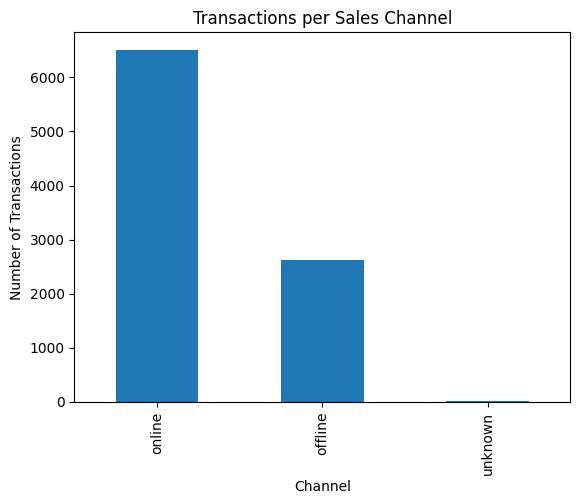

In [ ]:
# PURPOSE: Visualize the number of transactions for each sales channel.
# A bar chart makes the channel comparison easier to understand than a table alone.
# TALKING POINT: I use visualization to communicate the distribution of transactions clearly.

q1.plot(kind='bar')

plt.title('Transactions per Sales Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.show()


2- How many transactions involve each product? Count Product_Code occurrences.
- for each productcode how many times does it appear in the dataset



In [ ]:
# PURPOSE: Count how often each product code appears in the sales dataset.
# Each occurrence represents a transaction line involving that product.
# TALKING POINT: This identifies the products that appear most frequently in transactions.

sales['product_code'].value_counts().reset_index(name="transactions")

,product_code,transactions
0,e04,1154
1,f02,989
2,eg02,871
3,e05,793
4,eg03,789
5,p02,783
6,m01,773
7,p01,772
8,e02,765
9,a01,764


3- What is the average (mean) unit price across all products?

In [ ]:
# PURPOSE: Calculate the average unit price across all products after currency conversion.
# mean() calculates the arithmetic average of the USD unit-price column.
# TALKING POINT: This gives a simple overall measure of product pricing in the dataset.

avg_price = sales['unit_price_usd'].mean()
print("Average :", avg_price)

Average : 244.23594208981578


7- How many unique orders are there?


In [ ]:
# PURPOSE: Count the number of distinct orders.
# nunique() counts each order_id only once, even when an order contains multiple product rows.
# TALKING POINT: Transactions and orders are different because one order can contain several products.

unique_orders = sales['order_id'].nunique()
print("Number of unique orders:", unique_orders)

Number of unique orders: 8481


9- In 2024, which day of the week had the highest sales amount?

In [ ]:
# PURPOSE: Calculate total sales revenue for each weekday in 2024.
# I filter to 2024, group rows by weekday, sum total_amount, and sort from highest to lowest.
# TALKING POINT: This identifies which weekday generated the most revenue during 2024.

q9 = sales[sales['year'] == 2024].groupby('weekday_name')['total_amount'].sum().reset_index().sort_values('total_amount', ascending=False)




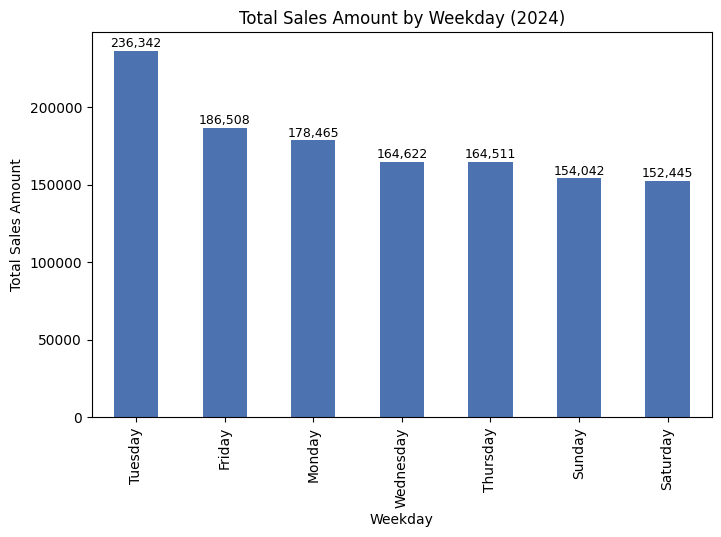

In [ ]:
# PURPOSE: Visualize 2024 revenue by weekday.
# The grouped sales values are plotted as bars, and the exact revenue is written above each bar.
# TALKING POINT: The chart makes the strongest and weakest weekdays immediately visible.

q9 = (
    sales[sales['year'] == 2024]
    .groupby('weekday_name')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

q9.plot(kind='bar', color='#4C72B0', figsize=(8,5))
plt.title('Total Sales Amount by Weekday (2024)')
plt.xlabel('Weekday')
plt.ylabel('Total Sales Amount')

# Add numbers on top of bars
for i, v in enumerate(q9):
    plt.text(i, v + (0.01 * max(q9)), f'{v:,.0f}', ha='center', fontsize=9)

plt.show()


11- The company is considering closing one of its sales channels in one country due to high operating costs. Using the data, which country and channel combination has the lowest number of transactions, and might be the best candidate for closure?


In [ ]:
# PURPOSE: Find the country-and-channel combination with the fewest transactions.
# I first keep only valid online/offline channels, then count each country-channel combination and sort ascending.
# TALKING POINT: The first row is the lowest-volume combination and therefore a possible candidate for further review.

valid_channels = sales[
    sales['channel'].isin(['online', 'offline'])
]

lowest = (
    valid_channels[['country', 'channel']]
    .value_counts()
    .reset_index(name='transactions')
    .sort_values('transactions')
)

lowest

,country,channel,transactions
3,lebanon,offline,466
2,jordan,offline,2163
1,jordan,online,2226
0,lebanon,online,4287


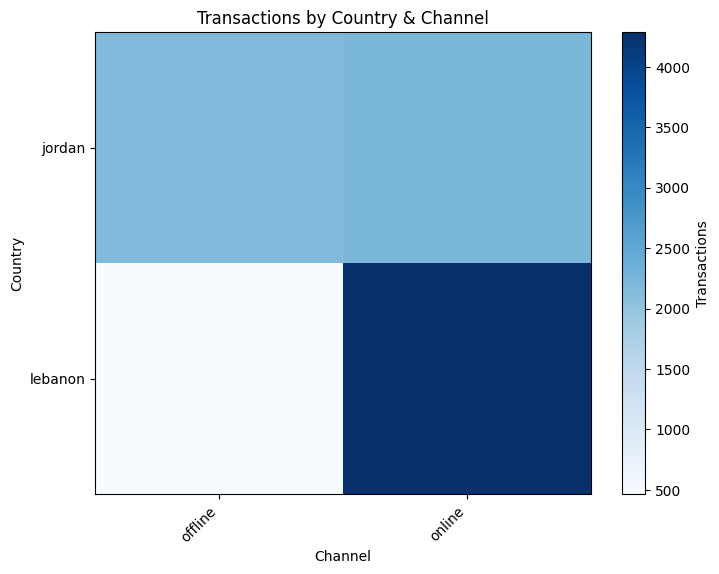

In [ ]:
# PURPOSE: Visualize transaction counts for each country and sales channel.
# The pivot reshapes the data into a country-by-channel matrix, which is then shown as a heatmap.
# TALKING POINT: Darker/lighter cells make differences between country-channel combinations easier to compare.

q11 = (
    valid_channels[['country','channel']]
    .value_counts()
    .reset_index(name='transactions')
    .pivot(index='country', columns='channel', values='transactions')
    .fillna(0)
)

plt.figure(figsize=(8,6))
plt.imshow(q11, cmap="Blues", aspect="auto")
plt.colorbar(label="Transactions")
plt.xticks(range(len(q11.columns)), q11.columns, rotation=45, ha='right')
plt.yticks(range(len(q11.index)), q11.index)
plt.title("Transactions by Country & Channel")
plt.xlabel("Channel")
plt.ylabel("Country")
plt.show()


12- Using the customers.csv file,


1.   identify the dominant sector among the loyal customer segment.
2.   Which city has the highest total sales volume (units sold) in Jordan via the online channel? Show the results sorted in descending order of sales volume.




In [ ]:
# PURPOSE: Combine customer information with sales data for customer and geographic analysis.
# First I standardize customer text fields so the keys match the cleaned sales dataset.
# Q12.1 merges loyal-customer sales with sector data, then counts which sector appears most often.
# Q12.2 filters Jordan online sales, merges customer city information, then sums units sold by city.
# TALKING POINT: merge() is used because the customer attributes are stored in a separate dataset.

# Standardize customers.csv columns
customers["customer_id"] = customers["customer_id"].str.strip().str.lower()
customers["channel"] = customers["channel"].str.strip().str.lower()
customers["city"] = customers["city"].str.strip().str.lower()
customers["sector"] = customers["sector"].str.strip().str.lower()


# -----------------------------------
# Q12.1 Dominant sector among Loyal customers
# -----------------------------------



loyal_with_sector = loyal_sales.merge(
    customers[["customer_id", "channel", "sector"]],
    on=["customer_id", "channel"],
    how="left"
)

dominant_sector = (
    loyal_with_sector[["customer_id", "sector"]]
    .drop_duplicates()
    ["sector"]
    .value_counts()
)

print("Dominant sector among loyal customers:")
print(dominant_sector)

print("\nDominant sector:", dominant_sector.idxmax())


# -----------------------------------
# Q12.2 Jordan online sales by city
# -----------------------------------

jordan_online = sales[
    (sales["country"] == "jordan") &
    (sales["channel"] == "online")
]

jordan_online = jordan_online.merge(
    customers[["customer_id", "channel", "city"]],
    on=["customer_id", "channel"],
    how="left"
)

city_sales = (
    jordan_online
    .groupby("city")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nOnline sales volume by city in Jordan:")
print(city_sales)

print(
    "\nCity with highest online sales volume:",
    city_sales.iloc[0]["city"],
    "-",
    city_sales.iloc[0]["units_sold"],
    "units"
)

Dominant sector among loyal customers:
sector
university    22
company       19
government     9
Name: count, dtype: int64

Dominant sector: university

Online sales volume by city in Jordan:
     city  units_sold
0   irbid        3915
1   aqaba         747
2  madaba         626
3   karak         457
4   amman         441
5   zarqa         361

City with highest online sales volume: irbid - 3915 units


13- Which products are most frequently sold together in the same order? List the top product pairs and how many times they occurred together?


In [ ]:
# PURPOSE: Find products that are frequently purchased together in the same order.
# I remove duplicate order-product combinations, self-merge by order_id, keep each pair only once,
# count how often each pair occurs, and sort from most common to least common.
# TALKING POINT: This is a simple market-basket style analysis of product relationships.

tmp = sales[["order_id","product"]].drop_duplicates()

pairs_df = (
    tmp.merge(tmp, on="order_id")
       .query("product_x < product_y")
       .groupby(["product_x","product_y"]).size()
       .reset_index(name="count")
       .sort_values("count", ascending=False)
)

pairs_df

,product_x,product_y,count
2,keyboard,mouse,383
0,chair,laptop,182
1,gaming chair,headset,101


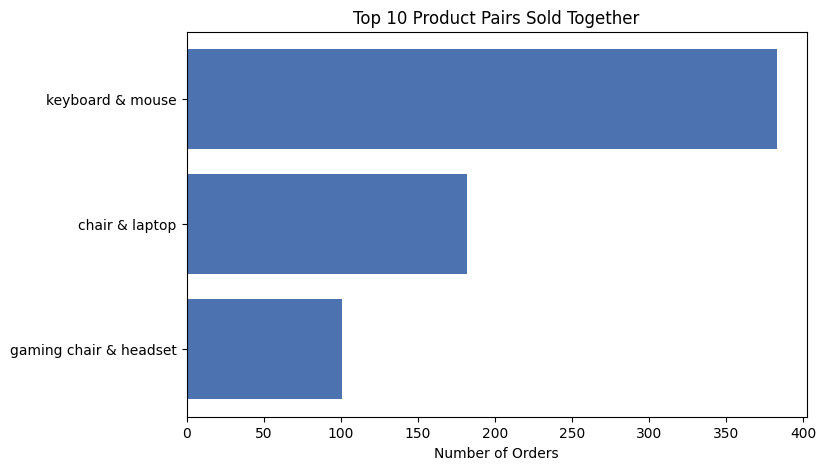

In [ ]:
# PURPOSE: Visualize the ten product pairs that occur together most often.
# A horizontal bar chart is used because product-pair names are easier to read this way.
# TALKING POINT: These combinations could be useful for bundles, recommendations, or cross-selling.

tmp = sales[['order_id','product']].drop_duplicates()
pairs_df = (
    tmp.merge(tmp, on='order_id')
      .query('product_x < product_y')
      .groupby(['product_x','product_y'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

top_pairs = pairs_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(
    top_pairs['product_x'] + " & " + top_pairs['product_y'],
    top_pairs['count'],
    color="#4C72B0"
)
plt.title("Top 10 Product Pairs Sold Together")
plt.xlabel("Number of Orders")
plt.gca().invert_yaxis()
plt.show()


14-*Which day of the week shows the highest sales for each product category? Create a heatmap showing sales volume by product and weekday?*


In [ ]:
# PURPOSE: Identify the weekday with the highest units sold for every product.
# I group by product and weekday, sum units, reshape weekdays into columns, then use idxmax() to find the best day.
# TALKING POINT: This shows that different products can have different strongest sales days.

highest_days = (
    sales.groupby(["product", "weekday_name"])["units_sold"]
    .sum()
    .unstack(fill_value=0)
    .idxmax(axis=1)
    .reset_index(name="day")
)

highest_days

,product,day
0,accessory,Monday
1,cable,Sunday
2,chair,Saturday
3,gaming chair,Saturday
4,headset,Saturday
5,keyboard,Friday
6,laptop,Tuesday
7,monitor,Tuesday
8,mouse,Sunday
9,phone,Tuesday


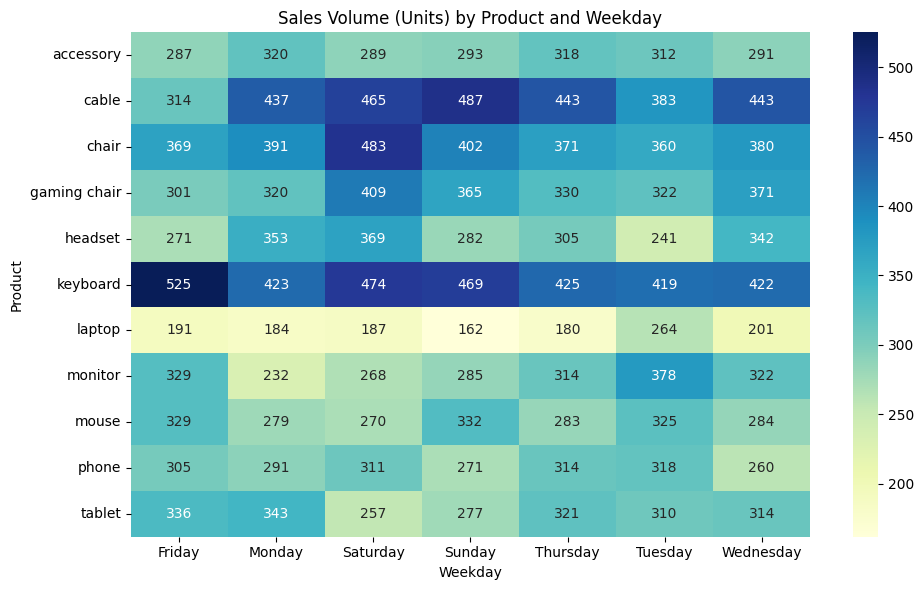

In [ ]:
# PURPOSE: Create a heatmap of units sold by product and weekday.
# The pivot table summarizes total units for every product-weekday combination.
# TALKING POINT: The heatmap reveals patterns that are harder to notice in a long numeric table.

pivot_table = (
    sales.groupby(["product", "weekday_name"])["units_sold"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Sales Volume (Units) by Product and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

15- Compare weekday sales trends for Jordan vs. Lebanon. Which weekdays are most profitable in each country?


In [ ]:
# PURPOSE: Compare the most profitable weekday in each country.
# I group by country and weekday, sum revenue, reshape the data, then find each country's maximum weekday and value.
# TALKING POINT: This shows whether Jordan and Lebanon have different weekly sales patterns.

result = (
    sales
    .groupby(["country", "weekday_name"])["total_amount"]
    .sum()
    .unstack(fill_value=0)
    .agg(["idxmax", "max"], axis=1)
    .rename(columns={
        "idxmax": "best_weekday",
        "max": "sales_amount"
    })
)

result

,best_weekday,sales_amount
country,,
jordan,Tuesday,446316.1548
lebanon,Tuesday,440634.713341


16- Find the top-performing salesperson per year (2022, 2023, 2024) based on total sales amount Show their total sales amount for each year


In [ ]:
# PURPOSE: Find the highest-performing salesperson in each selected year.
# I filter to 2022–2024, sum revenue by salesperson and year, sort descending, and keep the top person per year.
# TALKING POINT: Performance is measured here using total sales revenue generated.

years = [2022, 2023, 2024]

result = (
    sales[sales["year"].isin(years)]
          .groupby(["year","sales_person"])["total_amount"].sum()
         .reset_index()
         .sort_values(["year","total_amount"], ascending=[True,False])
         .groupby("year").head(1)
)

result


,year,sales_person,total_amount
2,2022,lina,246720.275089
10,2023,sami,274178.489796
12,2024,ahmed,256210.409100


18- Calculate the Year-over-Year (YoY) percentage change in sales for each country. Visualize the sales trends for all countries over the years. Based on your results, describe how each country is performing. Identify which country shows consistent growth, which is stable, and if any country shows declining trends.


In [ ]:
# PURPOSE: Calculate yearly sales and Year-over-Year percentage change for each country.
# I use only complete years through 2024, aggregate annual revenue, then pct_change() compares each year with the previous year.
# TALKING POINT: Positive YoY means growth; negative YoY means sales decreased from the previous year.

complete_years = sales[sales["year"] <= 2024]

yearly_sales = (
    complete_years
    .groupby(["year", "country"])["total_amount"]
    .sum()
    .reset_index()
    .sort_values(["country", "year"])
)

yearly_sales["yoy_change_%"] = (
    yearly_sales
    .groupby("country")["total_amount"]
    .pct_change() * 100
).round(2)

yearly_sales

,year,country,total_amount,yoy_change_%
0,2021,jordan,609812.239500,NaN
2,2022,jordan,596633.477100,-2.16
4,2023,jordan,624875.565600,4.73
6,2024,jordan,690836.648700,10.56
1,2021,lebanon,544885.823829,NaN
3,2022,lebanon,588096.873386,7.93
5,2023,lebanon,614502.691136,4.49
7,2024,lebanon,546097.810845,-11.13


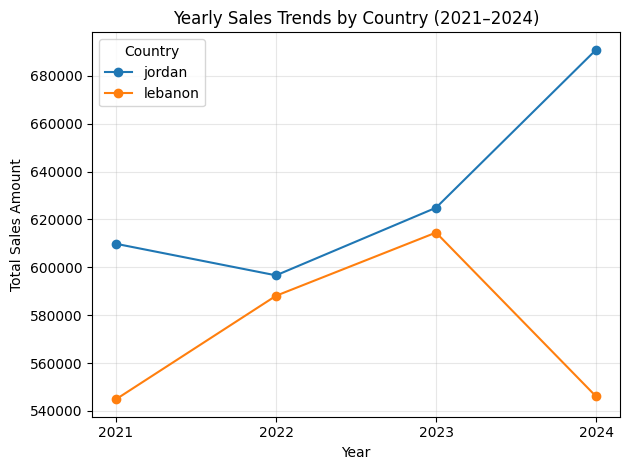

In [ ]:
# PURPOSE: Visualize annual sales trends for each country from 2021 to 2024.
# Each country is plotted as a separate line so their growth patterns can be compared over time.
# TALKING POINT: The line chart complements the YoY percentages by showing the overall direction of sales.

for country in yearly_sales["country"].unique():
    country_data = yearly_sales[
        yearly_sales["country"] == country
    ]

    plt.plot(
        country_data["year"],
        country_data["total_amount"],
        marker="o",
        label=country
    )

plt.title("Yearly Sales Trends by Country (2021–2024)")
plt.xlabel("Year")
plt.ylabel("Total Sales Amount")
plt.xticks([2021, 2022, 2023, 2024])
plt.legend(title="Country")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

19- Create a monthly summary report for each product showing total sales revenue, number of transactions, and total units sold.


*   Show the trend of total sales for a specific product over the months of 2024




In [ ]:
# PURPOSE: Build a monthly summary for every product.
# For each year-month-product group, I calculate total revenue, number of transaction rows, and total units sold.
# TALKING POINT: agg() lets me calculate several summary measures in one grouped analysis.

monthly_summary = (
    sales.groupby(["year","month","product"])
         .agg(
             total_revenue=("total_amount","sum"),
             num_transactions=("order_id","count"),
             total_units=("units_sold","sum")
         )
         .reset_index()
         .sort_values(["year","month","product"])
)

monthly_summary.head()


,year,month,product,total_revenue,num_transactions,total_units
0,2021,1,accessory,771.137400,9,26
1,2021,1,cable,499.961391,18,63
2,2021,1,chair,7885.729300,22,66
3,2021,1,gaming chair,6358.610300,13,29
4,2021,1,headset,3199.197900,17,46


In [ ]:
# PURPOSE: Select one example product, 'laptop', and isolate its monthly results for 2024.
# TALKING POINT: Filtering one product makes it possible to study its monthly sales pattern in detail.

product_name = "laptop"

trend_2024 = (
    monthly_summary[(monthly_summary["year"] == 2024) &
                    (monthly_summary["product"] == product_name)]
)

trend_2024


,year,month,product,total_revenue,num_transactions,total_units
402,2024,1,laptop,12337.980858,7,10
413,2024,2,laptop,40583.045985,12,32
424,2024,3,laptop,24644.877759,8,20
435,2024,4,laptop,32812.129375,13,27
446,2024,5,laptop,43328.009335,19,35
457,2024,6,laptop,35181.363619,16,29
468,2024,7,laptop,42293.540060,16,35
479,2024,8,laptop,26277.812755,11,22
490,2024,9,laptop,31741.125930,13,27
501,2024,10,laptop,26801.983961,11,21


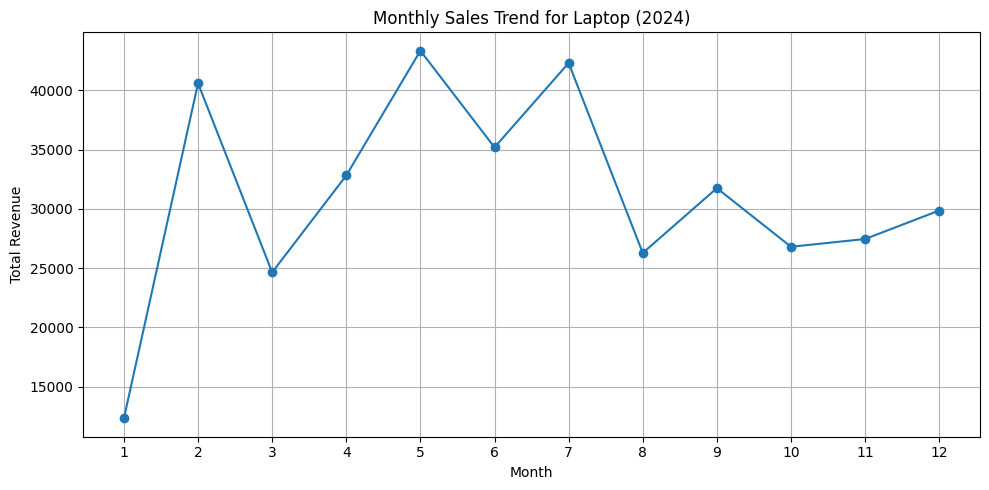

In [ ]:
# PURPOSE: Visualize the monthly revenue trend for laptops during 2024.
# The line chart shows whether laptop revenue rises, falls, or fluctuates from month to month.
# TALKING POINT: This turns the monthly summary table into an easier-to-read time trend.


plt.figure(figsize=(10,5))
plt.plot(trend_2024["month"], trend_2024["total_revenue"], marker="o")

plt.title(f"Monthly Sales Trend for {product_name.title()} (2024)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()
